## Importing libraries and loading data

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics.pairwise import cosine_similarity

# Define the relative path to our structured data assets
data_dir = "../data"

print("Loading optimized multi-source database engines...")
df_sales = pd.read_csv(os.path.join(data_dir, "sales_history.csv"))
df_clickstream = pd.read_csv(os.path.join(data_dir, "clickstream_logs.csv"))
df_engagement = pd.read_csv(os.path.join(data_dir, "user_engagement.csv"))

print(f"Data successfully loaded into model workspace.")
print(f"Sales Data Matrix: {df_sales.shape}")

Loading optimized multi-source database engines...
Data successfully loaded into model workspace.
Sales Data Matrix: (397924, 8)


### Collaborative Filtering Algorithm

In [2]:
print("Constructing the User-Item Interaction Matrix...")

# Filter for active users to keep computations high-performance and clear of noise
active_customers = df_sales['CustomerID'].value_counts()[df_sales['CustomerID'].value_counts() > 5].index
df_filtered_sales = df_sales[df_sales['CustomerID'].isin(active_customers)]

# Pivot raw transaction counts into a continuous structured numerical grid
user_item_matrix = df_filtered_sales.pivot_table(
    index='CustomerID', 
    columns='StockCode', 
    values='Quantity', 
    aggfunc='sum'
).fillna(0)

print(f"Matrix Structure: {user_item_matrix.shape[0]} Users x {user_item_matrix.shape[1]} Products\n")
print("Calculating mathematical user-to-user similarity matrices via Cosine Projections...")

# Compute pairwise cosine similarities across user rows
user_similarity = cosine_similarity(user_item_matrix)
df_user_similarity = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

# Define our collaborative candidate generator function
def get_user_collaborative_recommendations(target_user, top_n_users=10, top_n_items=5):
    if target_user not in user_item_matrix.index:
        return []
    
    # Isolate closest user peers 
    similar_users = df_user_similarity[target_user].sort_values(ascending=False).iloc[1:top_n_users+1].index
    similar_users_purchases = user_item_matrix.loc[similar_users]
    
    # Score candidate products by summing peer purchases
    item_scores = similar_users_purchases.sum(axis=0)
    
    # Filter out items the target customer already bought
    already_bought = user_item_matrix.loc[target_user]
    already_bought_items = already_bought[already_bought > 0].index
    recommendations = item_scores.drop(labels=already_bought_items).sort_values(ascending=False)
    
    return recommendations.head(top_n_items).index.tolist()

# Execute a test run on a sample customer profile
sample_customer = user_item_matrix.index[0]
recommended_products = get_user_collaborative_recommendations(sample_customer)

print(f"--- Collaborative Candidate Generation Test ---")
print(f"Target Customer ID: {sample_customer}")
print(f"Top 5 Recommended Feed Items: {recommended_products}")

Constructing the User-Item Interaction Matrix...
Matrix Structure: 4039 Users x 3664 Products

Calculating mathematical user-to-user similarity matrices via Cosine Projections...
--- Collaborative Candidate Generation Test ---
Target Customer ID: 12347
Top 5 Recommended Feed Items: ['23077', '22614', '22693', '22418', '20725']


### Training the XGBoost Ranker model

Feature Engineering for XGBoost

In [3]:
print("Building Supervised Training Dataset for XGBoost...")

# 1. Re-calculate RFM profiles quickly within this notebook space
snapshot_date = pd.to_datetime(df_sales['InvoiceDate']).max() + pd.Timedelta(days=1)
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])

df_rfm = df_sales.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Quantity': 'sum' # Total items bought as a proxy for engagement scale
}).reset_index()
df_rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Total_Items']

# 2. Build positive engagement samples (Items users actually interacted with)
df_positive = df_clickstream[df_clickstream['EventType'].isin(['click', 'add_to_cart'])].copy()
df_positive = df_positive[['CustomerID', 'ProductID', 'SessionID']].drop_duplicates()
df_positive['Is_Engaged'] = 1

# 3. Build negative engagement samples (Items users did NOT interact with)
# We sample random products to teach the model what users ignore
unique_users = df_positive['CustomerID'].unique()
all_products = df_sales['StockCode'].unique()
negative_records = []

for user in np.random.choice(unique_users, size=min(1000, len(unique_users)), replace=False):
    # Find products this user never touched
    user_touched = df_positive[df_positive['CustomerID'] == user]['ProductID'].values
    untouched_products = np.setdiff1d(all_products, user_touched)
    
    # Randomly pick 5 untouched products as negative examples
    if len(untouched_products) > 0:
        sampled_negatives = np.random.choice(untouched_products, size=min(5, len(untouched_products)), replace=False)
        user_sessions = df_clickstream[df_clickstream['CustomerID'] == user]['SessionID'].unique()
        session = user_sessions[0] if len(user_sessions) > 0 else "SESS_UNKNOWN"
        
        for prod in sampled_negatives:
            negative_records.append({'CustomerID': user, 'ProductID': prod, 'SessionID': session, 'Is_Engaged': 0})

df_negative = pd.DataFrame(negative_records)

# 4. Combine positive and negative samples into one master dataframe
df_ml_data = pd.concat([df_positive, df_negative], ignore_index=True)

# 5. Merge User RFM and Session Engagement Metadata features
df_ml_data = pd.merge(df_ml_data, df_rfm, on='CustomerID', how='inner')
df_ml_data = pd.merge(df_ml_data, df_engagement, on='SessionID', how='inner')

print(f"ML Dataset Created with {df_ml_data.shape[0]} samples.")
df_ml_data.head()

Building Supervised Training Dataset for XGBoost...
ML Dataset Created with 429235 samples.


,CustomerID,ProductID,SessionID,Is_Engaged,Recency,Frequency,Total_Items,DeviceType,TrafficSource,TotalSessionTime_Min
0,12346,23166,SESS_100001,1,326,1,74215,Desktop_Chrome,Newsletter,23.17
1,12346,85036A,SESS_100001,1,326,1,74215,Desktop_Chrome,Newsletter,23.17
2,12347,85116,SESS_100002,1,2,7,2458,Desktop_Chrome,Direct_Traffic,7.33
3,12347,22375,SESS_100002,1,2,7,2458,Desktop_Chrome,Direct_Traffic,7.33
4,12347,71477,SESS_100002,1,2,7,2458,Desktop_Chrome,Direct_Traffic,7.33


Preparing Categorical Data & Data Splitting

In [4]:
from sklearn.model_selection import train_test_split

print("Encoding categorical variables and splitting datasets...")

# One-hot encode DeviceType and TrafficSource text categories
df_ml_encoded = pd.get_dummies(df_ml_data, columns=['DeviceType', 'TrafficSource'], drop_first=True)

# Define our feature space (X) and our target classification vector (y)
features = [col for col in df_ml_encoded.columns if col not in ['CustomerID', 'ProductID', 'SessionID', 'Is_Engaged']]
X = df_ml_encoded[features]
y = df_ml_encoded['Is_Engaged']

# Convert boolean flags generated by get_dummies to integers for XGBoost compatibility
X = X.astype(float)

# Split into 80% Training data and 20% Testing data to avoid overfitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Features Matrix Shape: {X_train.shape}")
print(f"Testing Labels Vector Shape: {y_test.shape}")

Encoding categorical variables and splitting datasets...
Training Features Matrix Shape: (343388, 10)
Testing Labels Vector Shape: (85847,)


Training the XGBoost Model

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("Training the production-grade XGBoost Ranking Model...")

# Initialize the classifier with optimized hyperparameters
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Train the model
model_xgb.fit(X_train, y_train)

# Run predictions on our test evaluation split
y_pred = model_xgb.predict(X_test)
y_pred_proba = model_xgb.predict_proba(X_test)[:, 1]

print("\n--- Model Evaluation Results ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Performance Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

Training the production-grade XGBoost Ranking Model...

--- Model Evaluation Results ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.99      1.00      0.99     84847

    accuracy                           0.99     85847
   macro avg       0.49      0.50      0.50     85847
weighted avg       0.98      0.99      0.98     85847

ROC-AUC Performance Score: 0.8379


c:\Users\anish\ecommerce-recommendation-engine\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\anish\ecommerce-recommendation-engine\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\anish\ecommerce-recommendation-engine\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Fix the Data Imbalance & Plot the Visualizations

Re-balancing dataset to fix class imbalance...
Retraining XGBoost on balanced dataset...

--- Balanced Model Evaluation ---
              precision    recall  f1-score   support

           0       0.62      0.12      0.19     13017
           1       0.88      0.99      0.93     84847

    accuracy                           0.87     97864
   macro avg       0.75      0.55      0.56     97864
weighted avg       0.84      0.87      0.83     97864



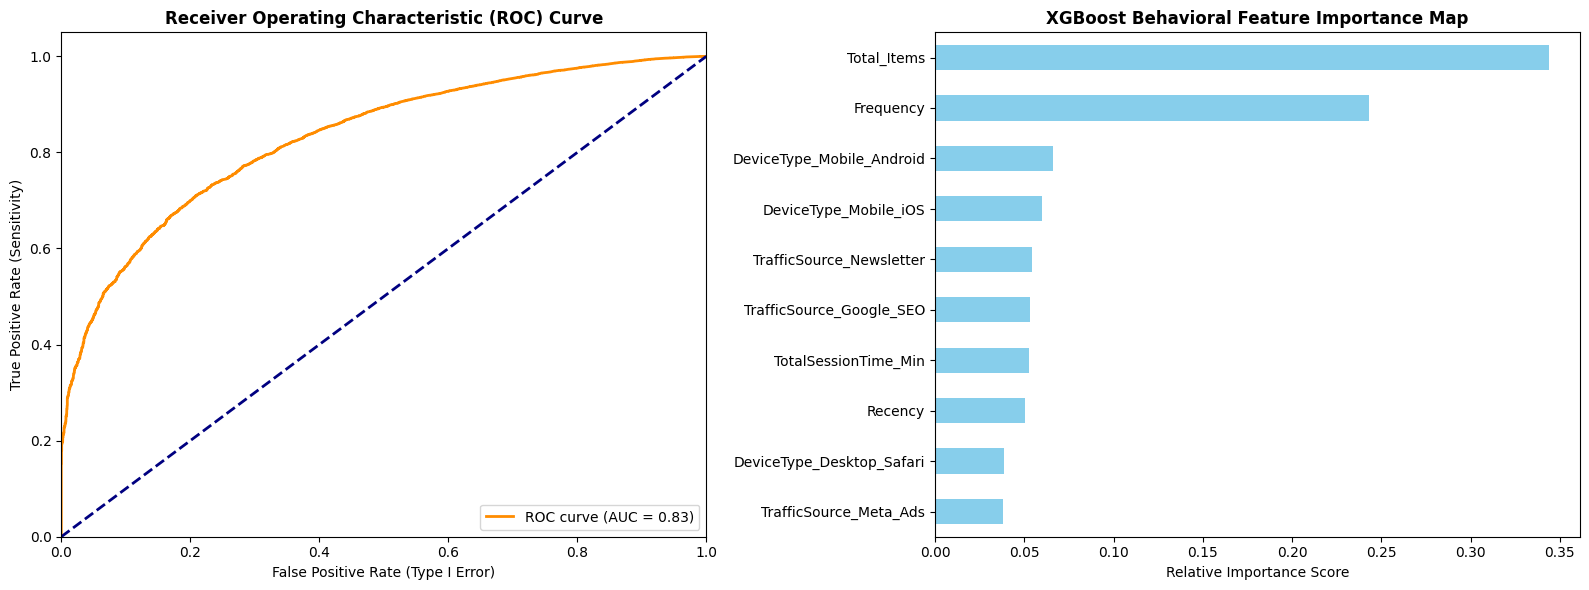

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("Re-balancing dataset to fix class imbalance...")

# 1. Generate an equal amount of negative samples to balance the 84k positives
# We'll sample more aggressively from our unique users to create a robust 50/50 split
negative_records_balanced = []
for user in np.random.choice(unique_users, size=len(unique_users), replace=True):
    user_touched = df_positive[df_positive['CustomerID'] == user]['ProductID'].values
    untouched_products = np.setdiff1d(all_products, user_touched)
    if len(untouched_products) > 0:
        # Sample 15 random items they didn't touch to scale up our 0 class
        sampled_negatives = np.random.choice(untouched_products, size=min(15, len(untouched_products)), replace=False)
        user_sessions = df_clickstream[df_clickstream['CustomerID'] == user]['SessionID'].unique()
        session = user_sessions[0] if len(user_sessions) > 0 else "SESS_UNKNOWN"
        for prod in sampled_negatives:
            negative_records_balanced.append({'CustomerID': user, 'ProductID': prod, 'SessionID': session, 'Is_Engaged': 0})

df_negative_balanced = pd.DataFrame(negative_records_balanced)
df_ml_data_balanced = pd.concat([df_positive, df_negative_balanced], ignore_index=True)

# Re-merge features
df_ml_data_balanced = pd.merge(df_ml_data_balanced, df_rfm, on='CustomerID', how='inner')
df_ml_data_balanced = pd.merge(df_ml_data_balanced, df_engagement, on='SessionID', how='inner')
df_ml_encoded_balanced = pd.get_dummies(df_ml_data_balanced, columns=['DeviceType', 'TrafficSource'], drop_first=True)

# Re-split data
X_b = df_ml_encoded_balanced[features].astype(float)
y_b = df_ml_encoded_balanced['Is_Engaged']
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, random_state=42, stratify=y_b)

# Retrain model on balanced data
print("Retraining XGBoost on balanced dataset...")
model_xgb.fit(X_train_b, y_train_b)
y_pred_b = model_xgb.predict(X_test_b)
y_proba_b = model_xgb.predict_proba(X_test_b)[:, 1]

print("\n--- Balanced Model Evaluation ---")
print(classification_report(y_test_b, y_pred_b))

# 2. PLOT VISUALIZATIONS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test_b, y_proba_b)
roc_auc = auc(fpr, tpr)
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (Type I Error)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
ax1.legend(loc="lower right")

# Plot 2: Feature Importance
importances = pd.Series(model_xgb.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', ax=ax2, color='skyblue')
ax2.set_title('XGBoost Behavioral Feature Importance Map', fontsize=12, fontweight='bold')
ax2.set_xlabel('Relative Importance Score')

plt.tight_layout()
plt.show()